In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All good!")

Matplotlib is building the font cache; this may take a moment.


All good!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/darshanv/credit-risk-scorer/data/application_train.csv')
print(f"Shape: {df.shape}")
print("Data loaded successfully!")

Shape: (307511, 122)
Data loaded successfully!


In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


In [8]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
# Most important — check your target variable (what you're predicting)
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean():.2%}")

TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


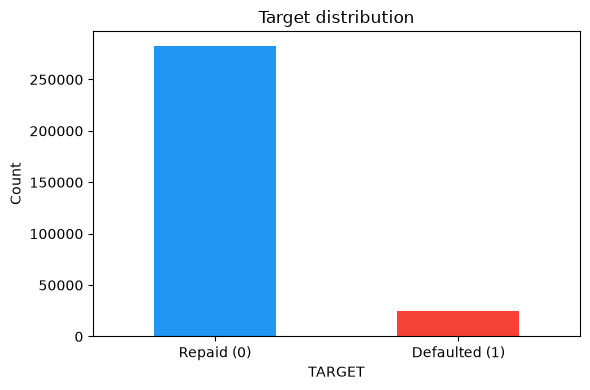

In [10]:
# Visualize the imbalance
fig, ax = plt.subplots(figsize=(6, 4))
df['TARGET'].value_counts().plot(kind='bar', ax=ax,
    color=['#2196F3', '#F44336'])
ax.set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)
ax.set_title('Target distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/target_distribution.png', dpi=150)
plt.show()

In [11]:
# Check missing values per column
missing = (df.isnull().sum() / len(df) * 100)
missing = missing[missing > 0].sort_values(ascending=False)
print(f"{len(missing)} columns have missing values\n")
print(missing.head(20))

67 columns have missing values

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64


In [12]:
# Check missing values per column
missing = (df.isnull().sum() / len(df) * 100)
missing = missing[missing > 0].sort_values(ascending=False)
print(f"{len(missing)} columns have missing values\n")
print(missing.head(20))

67 columns have missing values

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64


In [13]:
# Does number of missing values per row correlate with default?
df['null_count'] = df.isnull().sum(axis=1)
print(df.groupby('TARGET')['null_count'].mean())

TARGET
0    29.496473
1    32.798590
Name: null_count, dtype: float64


/var/folders/qf/k3qfl89s3hz2ym7jfndgvf300000gn/T/ipykernel_23051/3802124867.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['null_count'] = df.isnull().sum(axis=1)


In [14]:
# Check the most important features specifically
important = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print(df[important].isnull().sum() / len(df) * 100)


EXT_SOURCE_1    56.381073
EXT_SOURCE_2     0.214626
EXT_SOURCE_3    19.825307
dtype: float64


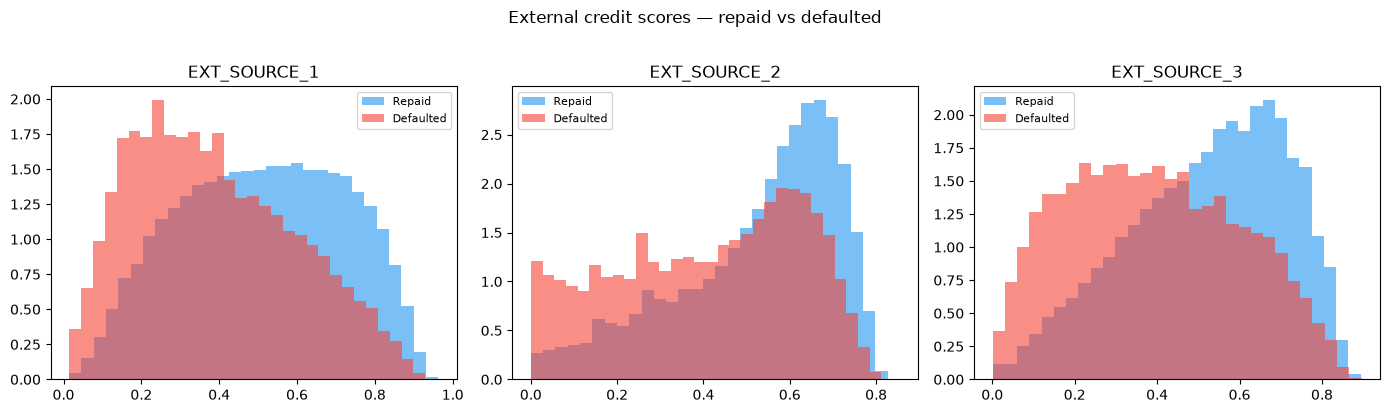

In [15]:
# Do higher external scores mean less default?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for target, label, color in [(0,'Repaid','#2196F3'),(1,'Defaulted','#F44336')]:
        subset = df[df['TARGET']==target][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6,
                     label=label, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.suptitle('External credit scores — repaid vs defaulted', y=1.02)
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/ext_scores.png', dpi=150)
plt.show()

/var/folders/qf/k3qfl89s3hz2ym7jfndgvf300000gn/T/ipykernel_23051/2691635817.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_years'] = -df['DAYS_BIRTH'] / 365


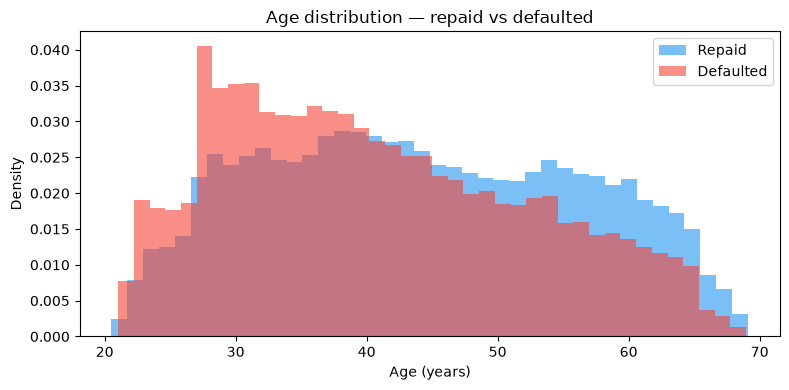

In [16]:
# Does age affect default rate?
df['age_years'] = -df['DAYS_BIRTH'] / 365

fig, ax = plt.subplots(figsize=(8, 4))
for target, label, color in [(0,'Repaid','#2196F3'),
                               (1,'Defaulted','#F44336')]:
    subset = df[df['TARGET']==target]['age_years']
    ax.hist(subset, bins=40, alpha=0.6,
            label=label, color=color, density=True)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age distribution — repaid vs defaulted')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/age_distribution.png', dpi=150)
plt.show()

/var/folders/qf/k3qfl89s3hz2ym7jfndgvf300000gn/T/ipykernel_23051/1628818653.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['income_annuity_ratio'] = df['AMT_INCOME_TOTAL'] / df['AMT_ANNUITY']


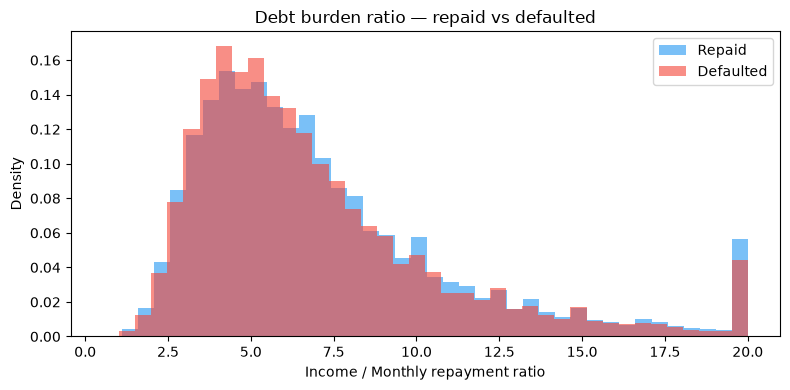

In [17]:
# Create income-to-annuity ratio (your engineered feature)
df['income_annuity_ratio'] = df['AMT_INCOME_TOTAL'] / df['AMT_ANNUITY']

fig, ax = plt.subplots(figsize=(8, 4))
for target, label, color in [(0,'Repaid','#2196F3'),
                               (1,'Defaulted','#F44336')]:
    subset = df[df['TARGET']==target]['income_annuity_ratio'].dropna()
    subset = subset.clip(0, 20)  # remove extreme outliers for clean plot
    ax.hist(subset, bins=40, alpha=0.6,
            label=label, color=color, density=True)
ax.set_xlabel('Income / Monthly repayment ratio')
ax.set_ylabel('Density')
ax.set_title('Debt burden ratio — repaid vs defaulted')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/debt_burden.png', dpi=150)
plt.show()

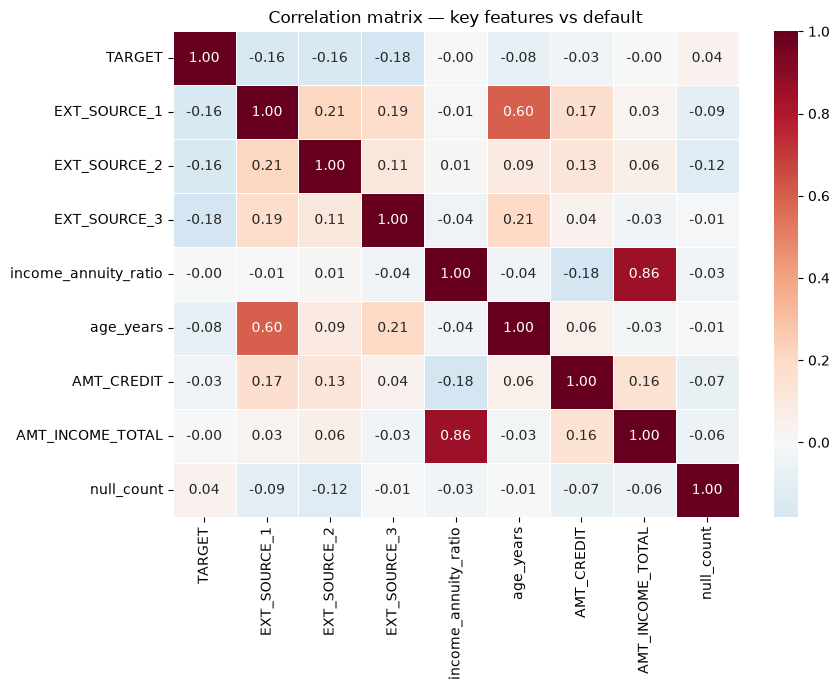

In [18]:
# Correlation of key features with TARGET
top_cols = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 
            'EXT_SOURCE_3', 'income_annuity_ratio', 
            'age_years', 'AMT_CREDIT', 
            'AMT_INCOME_TOTAL', 'null_count']

corr = df[top_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — key features vs default')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/correlation_heatmap.png', 
            dpi=150)
plt.show()

## EDA Summary
- Dataset: 307,511 applicants, 122 features, 8% default rate
- Strongest predictors: EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1
- Key engineered features created: age_years, income_annuity_ratio, null_count
- 67 columns have missing values — strategy: drop >40%, impute EXT_SOURCE
- Younger applicants and those with more missing fields are higher risk